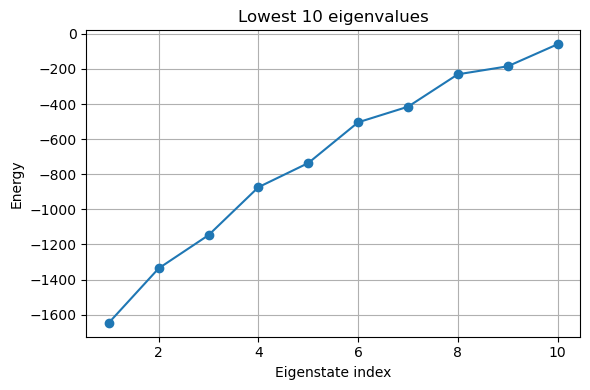

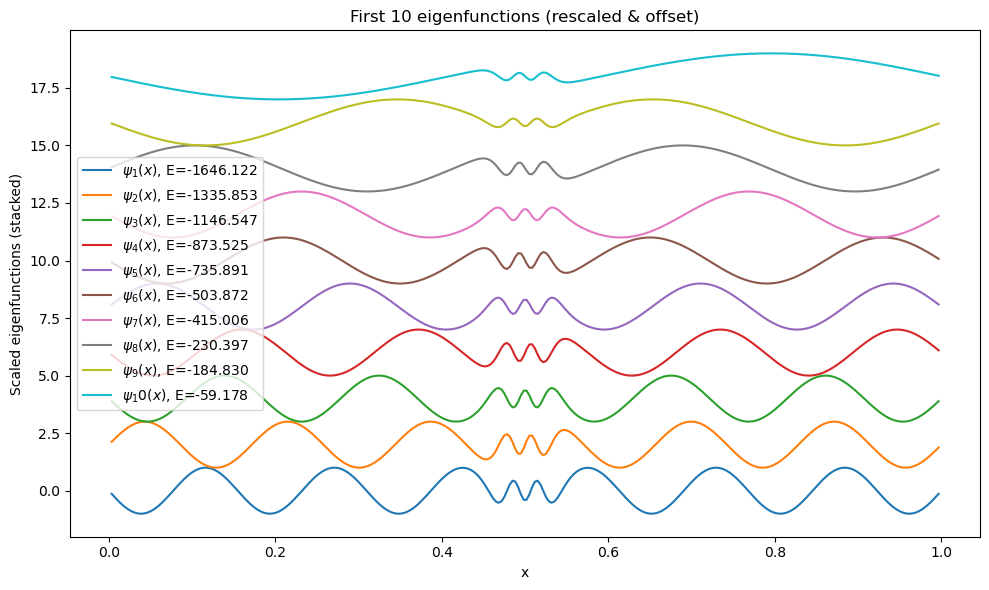

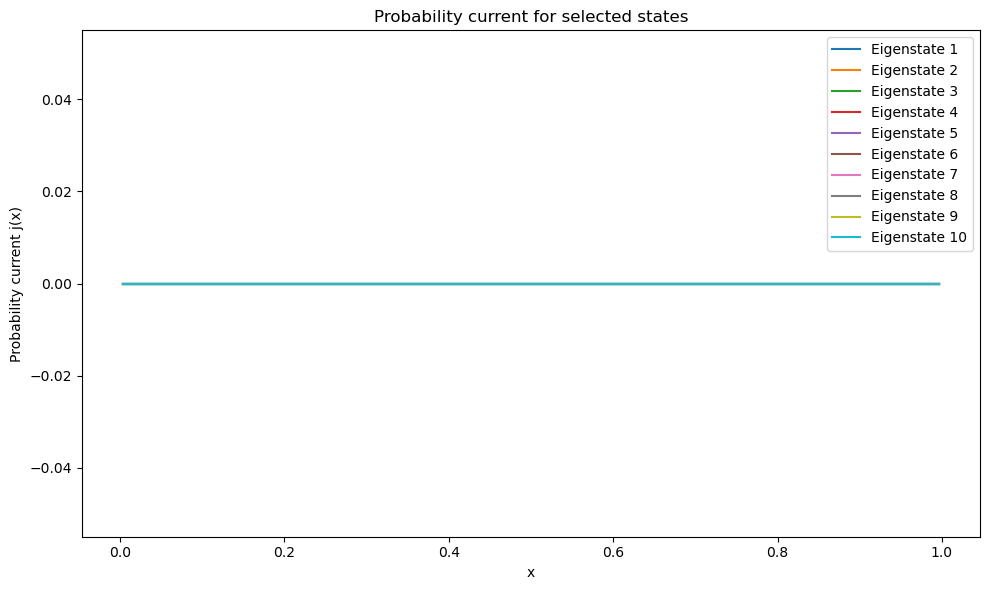

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

def solve_schrodinger_sparse(potential_func, n_points=200, n_eigs=10):
    """
    Solve the 1D Schrödinger equation on [0,1] with Dirichlet BCs, sparse version.

    H = -d^2/dx^2 + V(x), with units: ħ=1, m=1/2  =>  kinetic prefactor = 1
    Returns interior grid only (boundaries removed).

    Args:
        potential_func: callable V(x) on [0,1]
        n_points: total grid points including boundaries
        n_eigs: number of lowest eigenpairs to compute
    """
    if n_points < 4:
        raise ValueError("n_points must be >= 4.")

    # Uniform grid including boundaries; interior points for Dirichlet BCs
    xs = np.linspace(0.0, 1.0, n_points)
    dx = xs[1] - xs[0]
    x = xs[1:-1]  # interior only

    V = np.asarray(potential_func(x), dtype=float)

    # Sparse 1D Laplacian with Dirichlet BCs on the interior grid
    main = np.full(n_points - 2, 2.0) / dx**2
    off = np.full(n_points - 3, -1.0) / dx**2
    lap = diags([off, main, off], offsets=[-1, 0, 1], format="csr")

    # Hamiltonian
    H = -lap + diags(V, 0, format="csr")

    # ARPACK: lowest 'k' eigenpairs
    k = min(n_eigs, n_points - 3)  # safety: k < N for eigsh
    eigvals, eigvecs = eigsh(H, k=k, which="SM")

    # Sort
    idx = np.argsort(eigvals)
    eigvals = np.real(eigvals[idx])
    eigvecs = eigvecs[:, idx]

    # Normalize eigenfunctions to ∫|ψ|^2 dx = 1 on (0,1)
    for i in range(eigvecs.shape[1]):
        norm = np.sqrt(np.trapz(np.abs(eigvecs[:, i])**2, x))
        eigvecs[:, i] /= norm

    return x, eigvals, eigvecs


def spatial_derivative_dirichlet(x, psi):
    """
    Second-order accurate ∂x psi on interior nodes, using Dirichlet BCs ψ(0)=ψ(1)=0.
    psi is defined only on interior nodes; we add ghost zeros at boundaries.
    """
    dx = x[1] - x[0]
    # ghost boundaries (Dirichlet): ψ_0 = ψ_N = 0
    psi_full = np.zeros(psi.size + 2, dtype=psi.dtype)
    psi_full[1:-1] = psi

    # central differences on interior points w.r.t. full grid
    dpsi = (psi_full[2:] - psi_full[:-2]) / (2*dx)
    return dpsi  # same length as interior x


def probability_current(x, psi):
    """
    j(x) = 2 * Im(ψ* ∂x ψ)   (since ħ=1, m=1/2)
    """
    dpsi = spatial_derivative_dirichlet(x, psi)
    return 2.0 * np.imag(np.conj(psi) * dpsi)


def plot_eigs_and_modes(x, eigvals, eigvecs, n_show=10):
    n = min(n_show, eigvals.size)
    
    # Eigenvalues
    plt.figure(figsize=(6,4))
    plt.plot(np.arange(1, n+1), eigvals[:n], 'o-')
    plt.xlabel("Eigenstate index")
    plt.ylabel("Energy")
    plt.title(f"Lowest {n} eigenvalues")
    plt.grid(True)
    plt.tight_layout()
    
    # Eigenfunctions (rescaled to max amplitude = 1)
    plt.figure(figsize=(10,6))
    for i in range(n):
        psi = eigvecs[:, i]
        psi /= np.max(np.abs(psi))  # scale to [-1,1]
        plt.plot(x, psi + 2*i, label=fr"$\psi_{i+1}(x)$, E={eigvals[i]:.3f}")
    plt.xlabel("x")
    plt.ylabel("Scaled eigenfunctions (stacked)")
    plt.title(f"First {n} eigenfunctions (rescaled & offset)")
    plt.legend()
    plt.tight_layout()



def plot_currents(x, eigvecs, which=None, title_prefix="Eigenstate"):
    """
    Plot j(x) for selected eigenfunctions.
    Expect ~0 everywhere (numerically ~1e-15) for Dirichlet bound states.
    """
    if which is None:
        which = range(min(10, eigvecs.shape[1]))

    plt.figure(figsize=(10,6))
    for i in which:
        jx = probability_current(x, eigvecs[:, i])
        plt.plot(x, jx, label=f"{title_prefix} {i+1}")
    plt.xlabel("x")
    plt.ylabel("Probability current j(x)")
    plt.title("Probability current for selected states")
    plt.legend()
    plt.tight_layout()


def example_superposition_current(x, eigvecs, coeffs=None):
    """
    Demonstrate nonzero current using a complex superposition ψ = Σ c_n ψ_n.
    Dirichlet BCs still enforce j(0)=j(1)=0, but interior j(x) can be nonzero.
    """
    m = eigvecs.shape[1]
    if coeffs is None:
        # default: use first two modes with a relative phase
        coeffs = np.zeros(m, dtype=complex)
        coeffs[0] = 1.0
        coeffs[1] = 1.0j
    psi = eigvecs @ coeffs
    # normalize
    psi /= np.sqrt(np.trapz(np.abs(psi)**2, x))

    jx = probability_current(x, psi)

    plt.figure(figsize=(10,6))
    plt.plot(x, jx)
    plt.xlabel("x")
    plt.ylabel("j(x)")
    plt.title("Probability current for a complex superposition")
    plt.tight_layout()
    return psi, jx


if __name__ == "__main__":
    # Define your potential as a Python function on [0,1]
    # Example: harmonic well centered at 0.5
    def V(x):
        return 50000*np.exp(-(x-.5)**2/(1e-3))

    # Solve
    x, E, Psi = solve_schrodinger_sparse(V, n_points=300, n_eigs=12)

    # Plots: eigenvalues & eigenfunctions
    plot_eigs_and_modes(x, E, Psi, n_show=10)

    # Probability current for (stationary) eigenstates: ~zero everywhere
    plot_currents(x, Psi, which=range(10))

    # Optional: superposition that yields non-zer


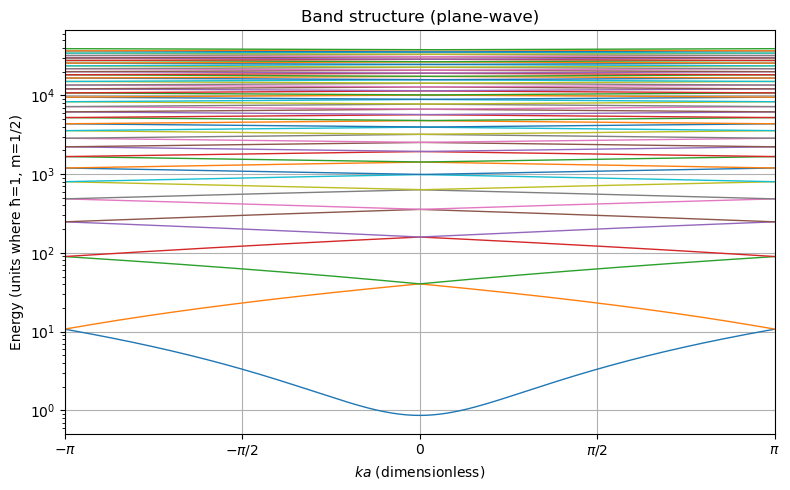

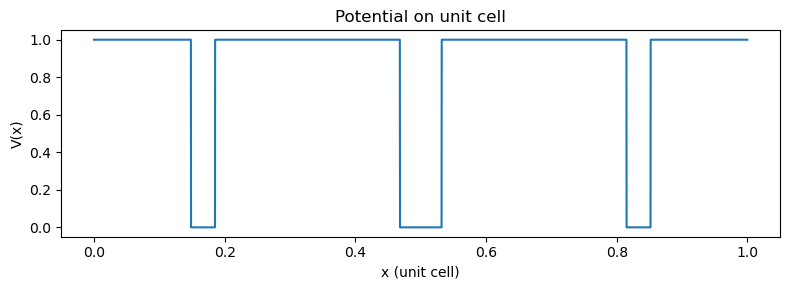

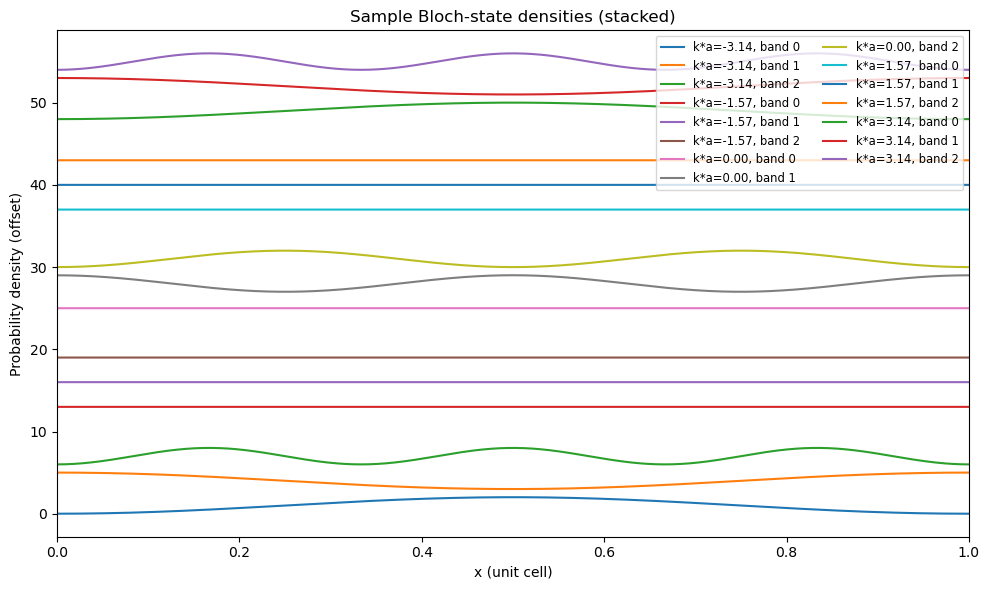

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq
from scipy.linalg import eigh

# ---------------------------
# Plane-wave / Bloch solver
# ---------------------------

def build_potential_fourier(V_func, a, n_grid=4096):
    """
    Sample V(x) on [0,a) and return Fourier coefficients V_G for G = 2π m / a.
    Uses FFT; output ordering corresponds to frequencies from -N...+N when sliced.
    """
    x = np.linspace(0, a, n_grid, endpoint=False)
    Vx = V_func(x)
    # FFT -> V_tilde_m with frequencies m = 0..n_grid-1 corresponding to
    # frequency 2π * m / a, we shift to negative frequencies via fftshift.
    Vk = fft(Vx) / n_grid  # normalization so inverse FFT is sum Vk exp(iGx)
    # Map FFT bins to G_m = 2π * m / a  with m in -n_grid/2..n_grid/2-1 after fftshift
    Vk_shifted = np.fft.fftshift(Vk)
    # return the shifted array together with its frequency indices m
    m_vals = np.arange(-n_grid//2, n_grid//2)
    # V_G theorem: V(x) = sum_m V_G exp(i G_m x) with G_m = 2π m / a
    return Vk_shifted, m_vals, x, Vx

def plane_wave_bandstructure(V_func, a=1.0, N_G=15, n_k=201, n_grid=4096):
    """
    Compute band structure using plane-wave basis.
    - V_func: callable V(x) on [0,a)
    - a: lattice constant (unit cell length)
    - N_G: use plane waves with m = -N_G..+N_G (total M = 2*N_G+1)
    - n_k: number of k-points across the 1D BZ [-pi/a, pi/a]
    - n_grid: grid for computing Fourier coefficients of V
    Returns:
      k_list, eigenvalues (n_k x M), eigenvectors (list of arrays of shape (M,M?) -> see below),
      G_list (array of G values), V_G (dict mapping m->V_G)
    Note: eigenvectors returned per k as columns in a matrix c_{G}.
    """
    # Fourier components of V
    Vk_shifted, m_vals, x_sample, Vx_sample = build_potential_fourier(V_func, a, n_grid=n_grid)

    # We will use G indices m = -N_G..N_G
    m_use = np.arange(-N_G, N_G+1)
    G_list = 2*np.pi * m_use / a
    M = len(m_use)

    # Map m (index in whole fftshift array) to corresponding value in Vk_shifted
    # fftshift index for m corresponds to index = (m + n_grid//2)
    def V_G(m):
        idx = int(m + n_grid//2)
        return Vk_shifted[idx]

    # Precompute V_{G-G'} matrix elements using convolution: V_{q} with q = G-G'
    Vmat = np.zeros((M, M), dtype=complex)
    for i, m_i in enumerate(m_use):
        for j, m_j in enumerate(m_use):
            m_diff = m_i - m_j
            Vmat[i, j] = V_G(m_diff)

    # k-grid in first Brillouin zone [-pi/a, pi/a]
    k_list = np.linspace(-np.pi/a, np.pi/a, n_k)

    eigvals_all = np.zeros((n_k, M))
    eigvecs_all = np.zeros((n_k, M, M), dtype=complex)  # eigvecs_all[k_idx,:,col] = eigenvector for band col

    for ik, k in enumerate(k_list):
        # Kinetic term: (k + G)^2 on diagonal
        kin = np.diag((k + G_list)**2)
        H = kin + Vmat
        # Hermitian (numerical) -> use eigh
        vals, vecs = eigh(H)
        eigvals_all[ik, :] = np.real(vals)
        eigvecs_all[ik, :, :] = vecs  # columns are eigenvectors c_G
    return {
        'k_list': k_list,
        'eigvals': eigvals_all,
        'eigvecs': eigvecs_all,
        'G_list': G_list,
        'm_use': m_use,
        'x_sample': x_sample,
        'Vx_sample': Vx_sample,
        'a': a
    }

def reconstruct_bloch(ck, k, G_list, x, a):
    """
    Reconstruct the Bloch function psi_k(x) = sum_G c_G * exp(i (k+G) x) / sqrt(a)
    - ck: vector of coefficients c_G (length M)
    - k: crystal momentum
    - G_list: array of G values of same length
    - x: real-space points on [0,a)
    - normalization uses 1/sqrt(a) to keep periodic cell normalization
    Returns psi(x) on same x.
    """
    phase = np.exp(1j * np.outer(k + G_list, x))  # shape (M, len(x))
    psi = (ck[:, None] * phase).sum(axis=0) / np.sqrt(a)
    # Normalize over cell
    norm = np.sqrt(np.trapz(np.abs(psi)**2, x))
    if norm == 0:
        return psi
    return psi / norm

# ---------------------------
# Example usage
# ---------------------------

if __name__ == "__main__":
    # Example periodic potential: cosine (simple "nearly-free electron" model)
    a = 1.0         # lattice constant
    V0 = 1.0        # amplitude
    def V_cos(x):
        return V0 * np.cos(2*np.pi * x / a)

    # Alternatively: periodic array of square wells
    def V_sq(x, well_width=0.2*a, depth= -20.0):
        # well centered at 0; repeat on [0,a)
        x0 = (x + 0.5*a) % a - 0.5*a  # center at 0
        return np.where(np.abs(x0) < well_width/2, depth, 0.0)

    def V_multi_well(x):
        return (0.5*(np.cos(6*np.pi*x/a)+1)>0.1) - 0.5

    def V_multi_well_2(x):
        return ((0.5*(np.cos(6*np.pi*x/a)+1)>0.03) * (0.5*(np.cos(2*np.pi*x/a)+1)>0.01))# - 0.5
    # Choose potential here
    #V = V_cos
    #V = V_sq
    V = V_multi_well_2

    # Compute bandstructure
    N_G = 31         # number of G on each side -> total M = 2*N_G + 1 (use odd for symmetry)
    n_k = 401
    result = plane_wave_bandstructure(V, a=a, N_G=N_G, n_k=n_k, n_grid=8192)

    k_list = result['k_list']
    eigvals = result['eigvals']
    eigvecs = result['eigvecs']
    G_list = result['G_list']
    x_sample = np.linspace(0, a, 1000, endpoint=False)  # for reconstructing Bloch functions

    # Plot band structure
    plt.figure(figsize=(8,5))
    for band in range(eigvals.shape[1]):
        plt.plot(k_list * a, eigvals[:, band], '-', lw=1)  # plot k*a so x-axis in units of pi (zone)
    plt.xlabel(r'$ka$ (dimensionless)')
    plt.ylabel('Energy (units where ħ=1, m=1/2)')
    plt.yscale('log')
    plt.title('Band structure (plane-wave)')
    plt.xlim(k_list[0]*a, k_list[-1]*a)
    plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
               [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
    plt.grid(True)
    plt.tight_layout()

    # Plot the potential on the unit cell
    xV = result['x_sample']
    Vx = result['Vx_sample']
    plt.figure(figsize=(8,3))
    plt.plot(xV, Vx)
    plt.xlabel('x (unit cell)')
    plt.ylabel('V(x)')
    plt.title('Potential on unit cell')
    plt.tight_layout()

    # Reconstruct and plot a few Bloch states (probability density) across the cell
    bands_to_plot = [0, 1, 2]   # lowest few bands
    k_indices = [0, n_k//4, n_k//2, 3*n_k//4, n_k-1]  # sample k: left-edge, quarter, Gamma, etc.
    plt.figure(figsize=(10,6))
    for i_k in k_indices:
        k = k_list[i_k]
        for b in bands_to_plot:
            ck = eigvecs[i_k, :, b]  # column b at k
            psi = reconstruct_bloch(ck, k, G_list, x_sample, a)
            # plot density, offset vertically for clarity
            label = f'k*a={k*a:.2f}, band {b}'
            plt.plot(x_sample, np.abs(psi)**2 + 3*(b + 0.2*(i_k/len(k_indices))), label=label)
    plt.xlabel('x (unit cell)')
    plt.ylabel('Probability density (offset)')
    plt.title('Sample Bloch-state densities (stacked)')
    plt.legend(fontsize='small', ncol=2)
    plt.xlim(0, a)
    plt.tight_layout()
    plt.show()
